# 02 — Modelo Exacto HDM (Gurobi)

Análisis de las soluciones exactas obtenidas con Gurobi para instancias
de distintos radios del casco histórico de San Cristóbal de La Laguna.

## 1. Carga de soluciones
   - Recorrer output/exacto_*/solucion_exacta.pkl
   - Tabla resumen: radio, edificios, candidatos, coste, gap, tiempo, puntos, bins

In [ ]:
import sys, os, pickle, json, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sys.path.insert(0, "../src/python")
from instancia import load_instance

# ── Buscar todas las soluciones exactas disponibles ───────
results = []
for sol_dir in sorted(glob.glob("../output/exacto_*m")):
    pkl_path = os.path.join(sol_dir, "solucion_exacta.pkl")
    json_path = os.path.join(sol_dir, "solucion_exacta_resumen.json")
    
    if not os.path.exists(pkl_path):
        continue
    
    # Extraer radio del nombre del directorio
    radius = int(sol_dir.split("_")[-1].replace("m", ""))
    
    # Cargar pickle
    with open(pkl_path, "rb") as f:
        sol = pickle.load(f)
    
    # Cargar resumen JSON si existe
    meta = {}
    if os.path.exists(json_path):
        with open(json_path) as f:
            meta = json.load(f)
    
    # Cargar instancia para contexto
    inst_path = f"../data/processed/instancia_laguna_{radius}m.json"
    inst = load_instance(inst_path) if os.path.exists(inst_path) else None
    
    n_open = sum(1 for v in sol["z"].values() if v == 1)
    n_bins = sum(sol["x"].values())
    
    results.append({
        "radius": radius,
        "buildings": len(inst.I) if inst else "?",
        "candidates": len(inst.J) if inst else "?",
        "cost": sol["cost"],
        "gap": sol.get("gap_gurobi", meta.get("gap", "?")),
        "runtime": meta.get("runtime", "?"),
        "points_open": n_open,
        "total_bins": n_bins,
        "sol": sol,
        "inst": inst,
    })

print(f"Soluciones encontradas: {len(results)}")
for r in results:
    print(f"  {r['radius']:>5}m | {r['cost']:>10,.1f}€ | {r['points_open']} puntos | {r['total_bins']} bins | gap {r['gap']}")

Soluciones encontradas: 7
    250m |  146,250.0€ | 29 puntos | 80 bins | gap 0.0
    300m |  206,500.0€ | 40 puntos | 113 bins | gap 0.0
    350m |  255,750.0€ | 49 puntos | 138 bins | gap 0.0
    400m |  327,100.0€ | 62 puntos | 177 bins | gap 0.0
    450m |  388,500.0€ | 74 puntos | 211 bins | gap 0.0
    500m |  476,150.0€ | 91 puntos | 258 bins | gap 0.0
    550m |  560,150.0€ | 107 puntos | 304 bins | gap 8.926180487369455e-05


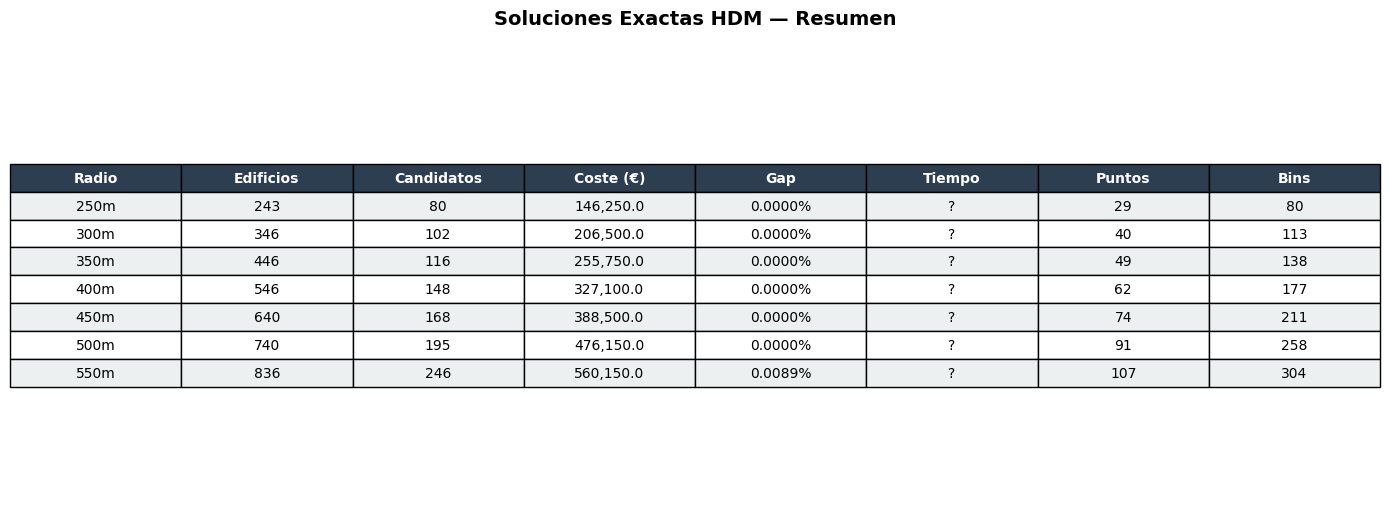

In [2]:
fig, ax = plt.subplots(figsize=(14, max(3, len(results) * 0.6 + 1)))
ax.axis("off")

headers = ["Radio", "Edificios", "Candidatos", "Coste (€)", "Gap", "Tiempo", "Puntos", "Bins"]
rows = []
for r in results:
    runtime = f"{r['runtime']:.1f}s" if isinstance(r['runtime'], (int, float)) else str(r['runtime'])
    gap = f"{r['gap']:.4%}" if isinstance(r['gap'], float) else str(r['gap'])
    rows.append([
        f"{r['radius']}m",
        str(r['buildings']),
        str(r['candidates']),
        f"{r['cost']:,.1f}",
        gap,
        runtime,
        str(r['points_open']),
        str(r['total_bins']),
    ])

table = ax.table(
    cellText=rows, colLabels=headers,
    loc="center", cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

# Estilo cabecera
for j in range(len(headers)):
    table[0, j].set_facecolor("#2c3e50")
    table[0, j].set_text_props(color="white", fontweight="bold")

# Alternar colores filas
for i in range(len(rows)):
    color = "#ecf0f1" if i % 2 == 0 else "white"
    for j in range(len(headers)):
        table[i + 1, j].set_facecolor(color)

plt.title("Soluciones Exactas HDM — Resumen", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

## 2. Visualización por instancia
   - Mapa con asignaciones (el que ya tienes para 500m)
   - Distribución de bins por punto

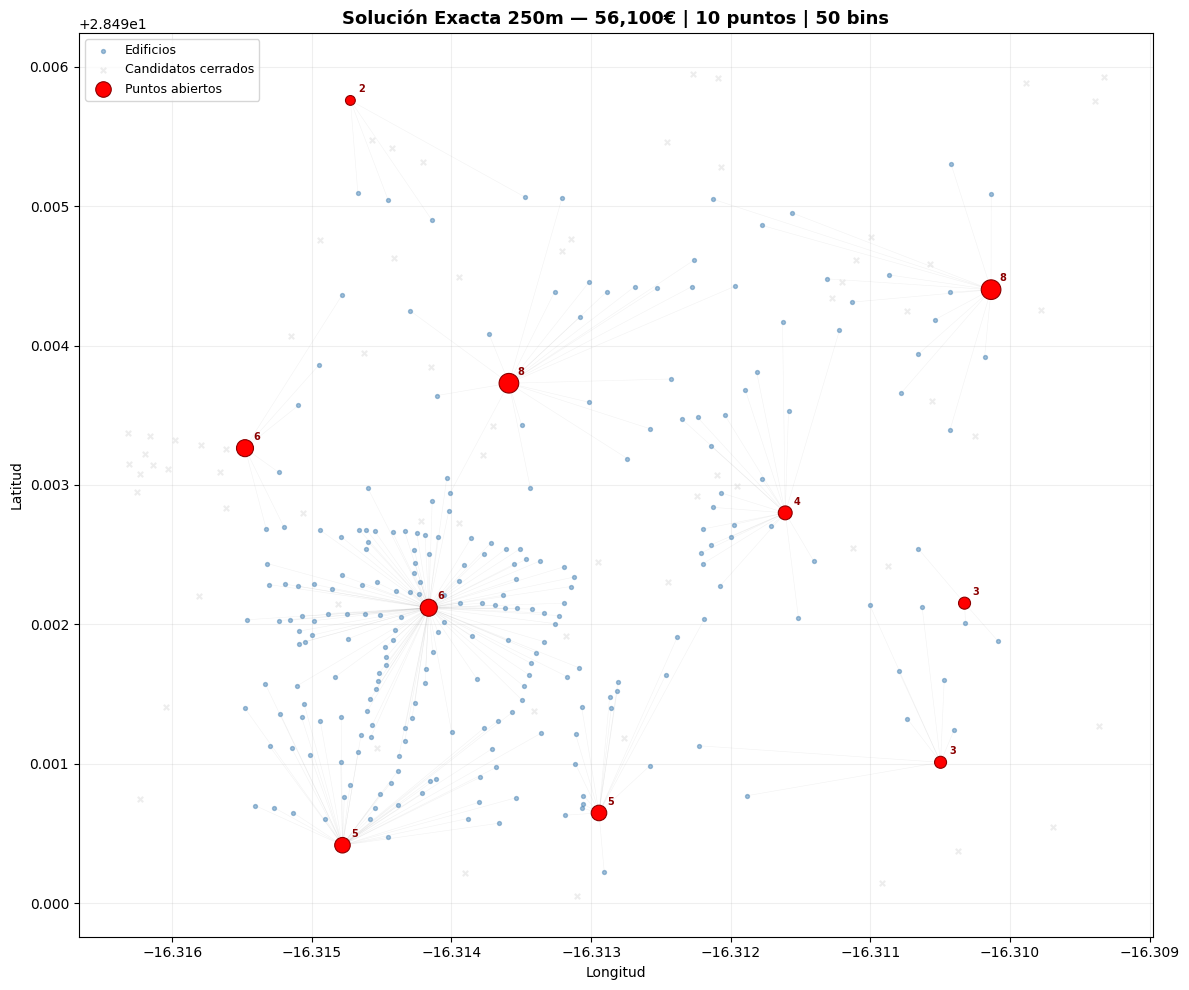

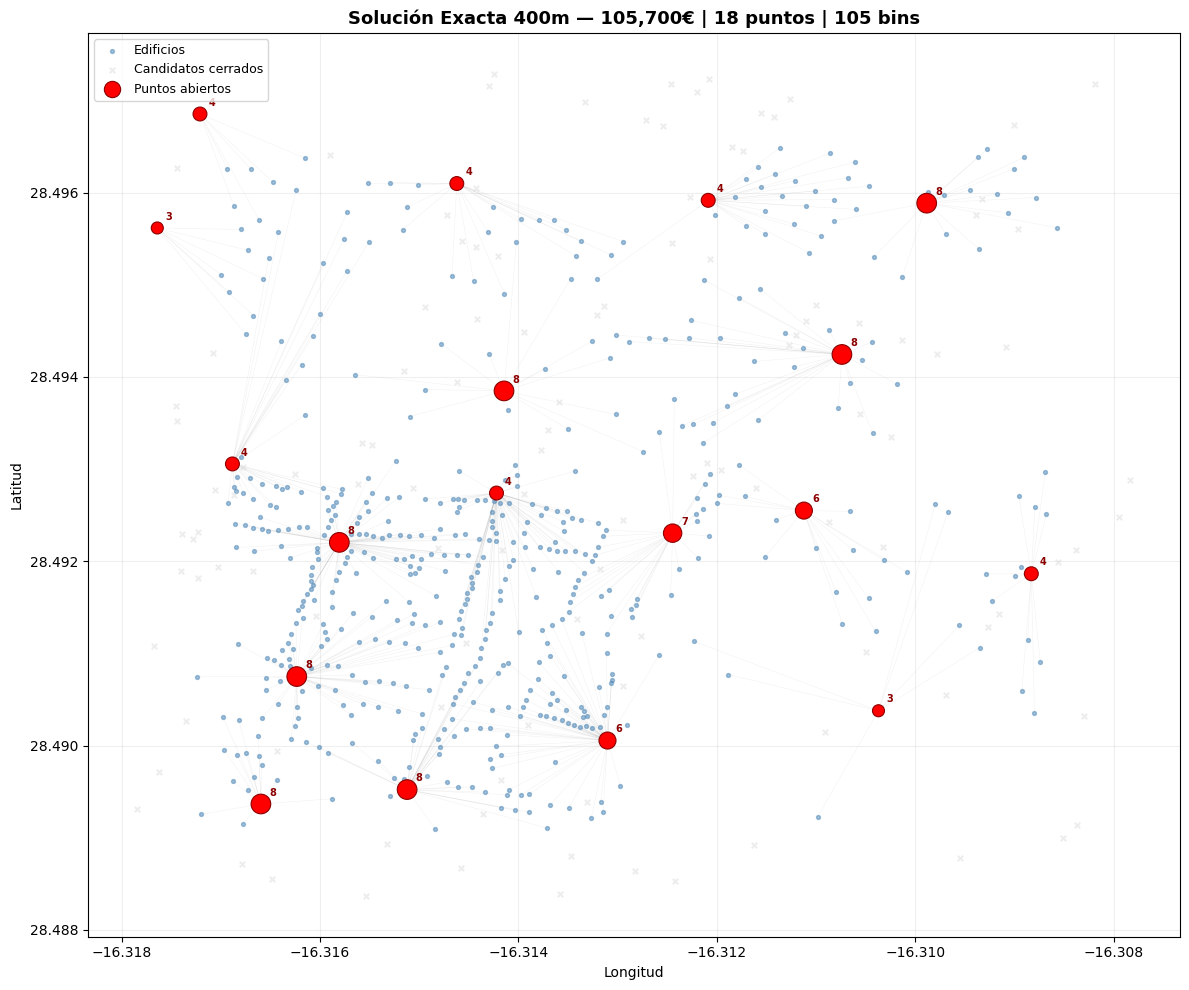

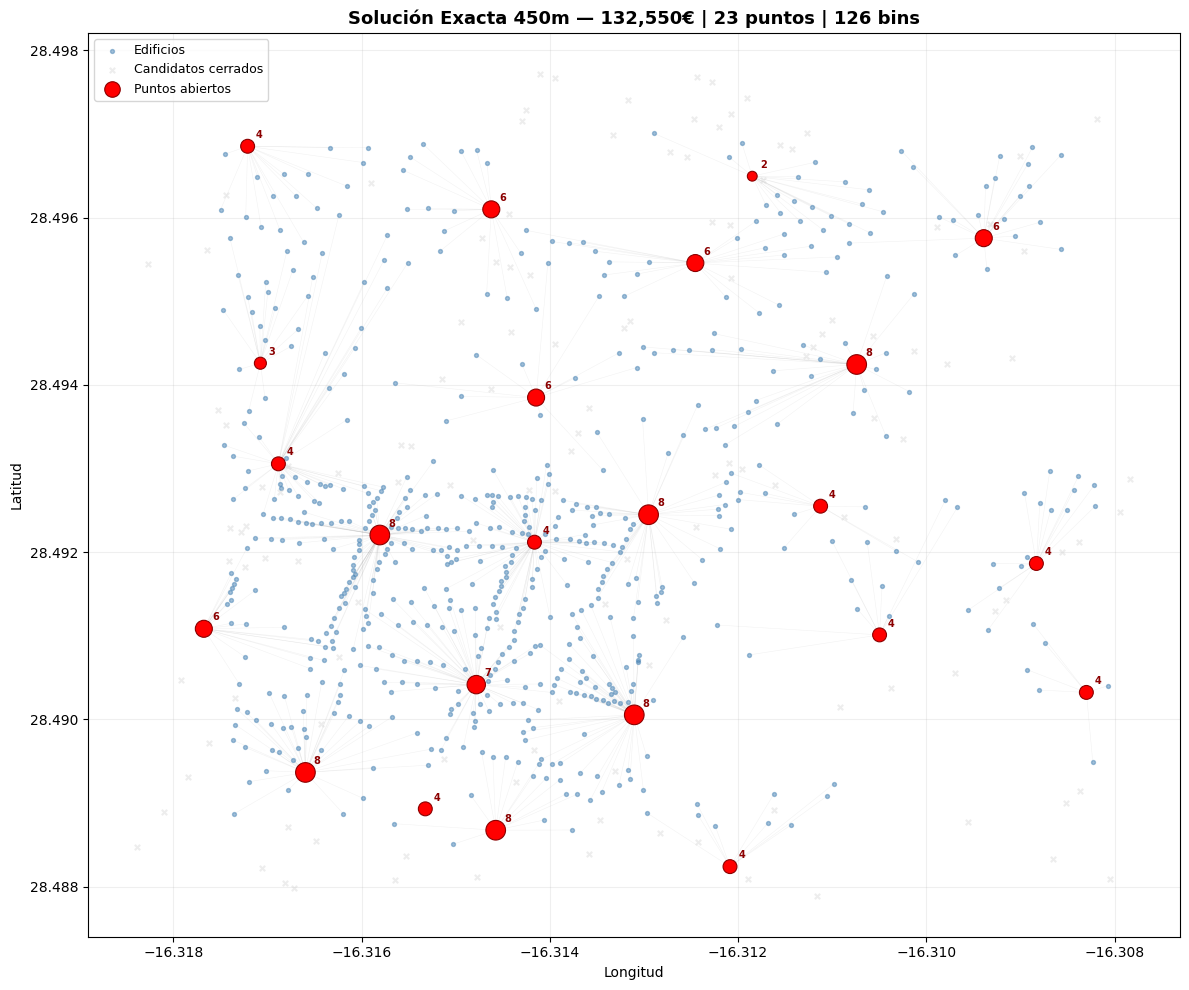

In [12]:
def plot_exact_solution(result):
    """Mapa de la solución exacta para una instancia."""
    sol, inst, radius = result["sol"], result["inst"], result["radius"]
    if inst is None:
        print(f"  Instancia {radius}m no disponible")
        return
    
    n_i, n_j = len(inst.I), len(inst.J)
    bld_lon = np.array([inst.I[i].longitude for i in range(n_i)])
    bld_lat = np.array([inst.I[i].latitude for i in range(n_i)])
    cand_lon = np.array([inst.J[j].longitude for j in range(n_j)])
    cand_lat = np.array([inst.J[j].latitude for j in range(n_j)])
    
    open_idx = [j for j, v in sol["z"].items() if v == 1]
    closed_idx = [j for j, v in sol["z"].items() if v == 0]
    bins_total = {j: sum(sol["x"].get((j, k), 0) for k in range(4)) for j in open_idx}
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Asignaciones k=0
    for (i, k), j in sol["y_assign"].items():
        if k == 0:
            ax.plot([bld_lon[i], cand_lon[j]], [bld_lat[i], cand_lat[j]],
                    color="gray", alpha=0.1, linewidth=0.4)
    
    ax.scatter(bld_lon, bld_lat, s=8, c="steelblue", alpha=0.5, zorder=3, label="Edificios")
    ax.scatter(cand_lon[closed_idx], cand_lat[closed_idx], s=15, c="lightgray",
               marker="x", alpha=0.4, zorder=4, label="Candidatos cerrados")
    
    sizes = [bins_total[j] * 25 for j in open_idx]
    ax.scatter(cand_lon[open_idx], cand_lat[open_idx], s=sizes, c="red",
               edgecolors="darkred", linewidth=0.8, zorder=5, label="Puntos abiertos")
    
    for j in open_idx:
        ax.annotate(str(bins_total[j]), (cand_lon[j], cand_lat[j]),
                    textcoords="offset points", xytext=(6, 6),
                    fontsize=7, fontweight="bold", color="darkred")
    
    ax.legend(loc="upper left", fontsize=9)
    ax.set_title(f"Solución Exacta {radius}m — {sol['cost']:,.0f}€ | "
                 f"{len(open_idx)} puntos | {sum(bins_total.values())} bins",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

# Visualizar todas las disponibles
for r in results:
    plot_exact_solution(r)

/home/guillermo/TFG-Optimizacion-Residuos/venv/lib/python3.8/site-packages/geopandas/plotting.py:695: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  warnings.warn(


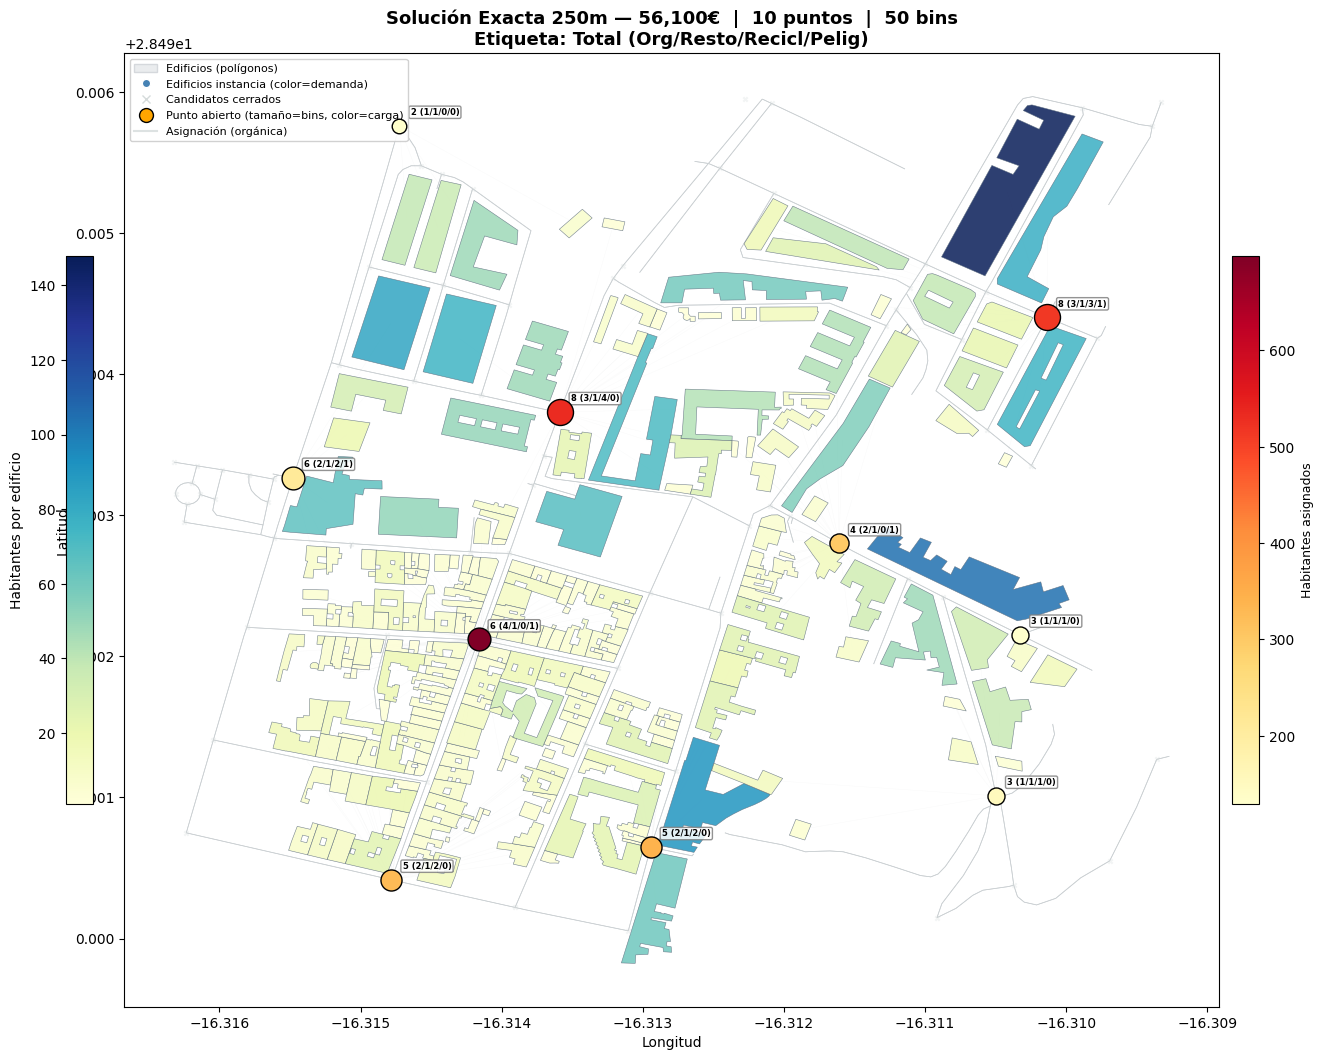

/home/guillermo/TFG-Optimizacion-Residuos/venv/lib/python3.8/site-packages/geopandas/plotting.py:695: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  warnings.warn(


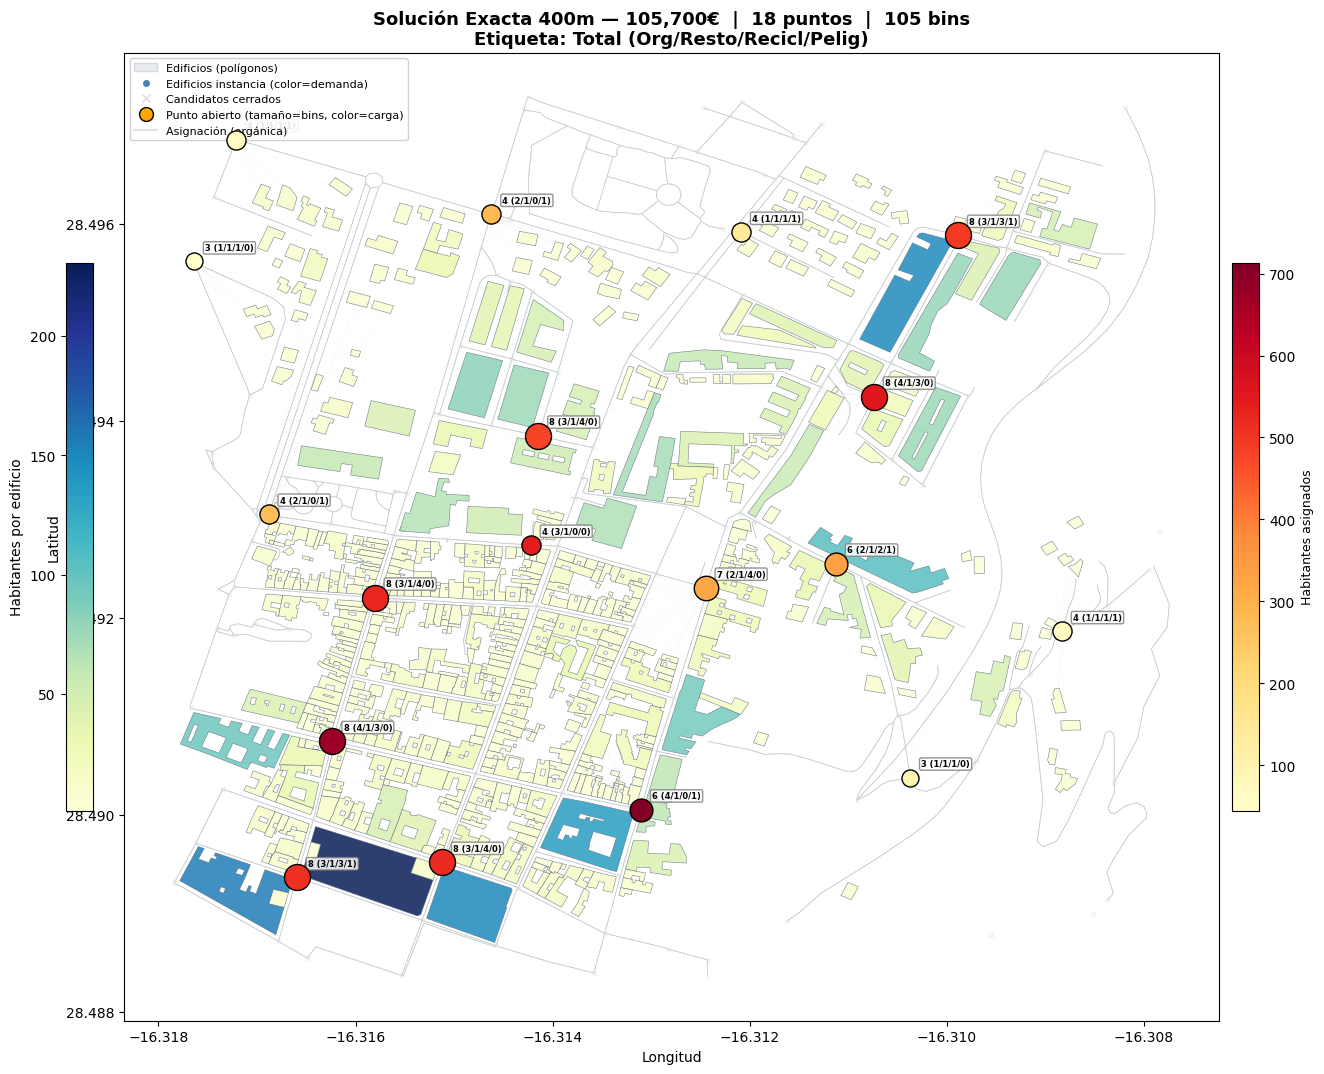

/home/guillermo/TFG-Optimizacion-Residuos/venv/lib/python3.8/site-packages/geopandas/plotting.py:695: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  warnings.warn(


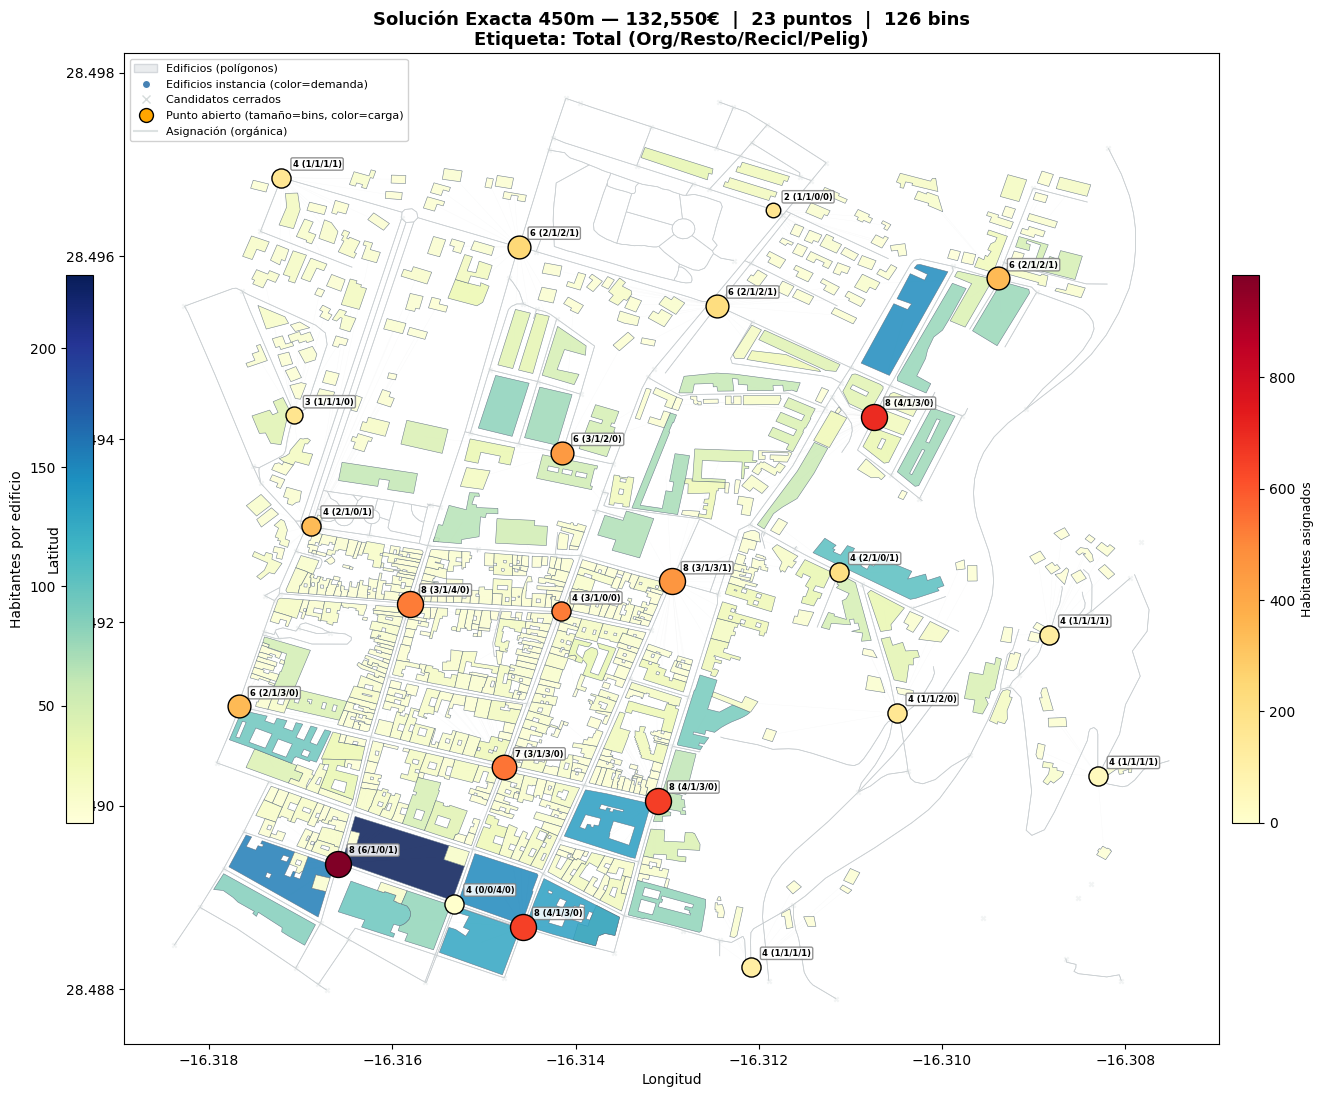

In [13]:
import geopandas as gpd
import osmnx as ox
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

def plot_rich_solution(result, figsize=(16, 14)):
    """Mapa avanzado: calles, edificios por demanda, puntos por carga."""
    sol, inst, radius = result["sol"], result["inst"], result["radius"]
    if inst is None:
        print(f"  Instancia {radius}m no disponible")
        return

    n_i, n_j, n_k = len(inst.I), len(inst.J), len(inst.K)

    # ── 1. Cargar grafo y edificios desde archivos locales ──
    graph_path = f"../data/processed/graph_{radius}m.graphml"
    bld_path = f"../data/processed/buildings_{radius}m.geojson"

    has_osm = os.path.exists(graph_path) and os.path.exists(bld_path)
    if has_osm:
        G = ox.load_graphml(graph_path)
        
        # Cargar GeoJSON sin fiona (evita incompatibilidad de versiones)
        import json as json_mod
        from shapely.geometry import shape
        with open(bld_path) as f:
            geojson_data = json_mod.load(f)
        geometries = [shape(feat["geometry"]) for feat in geojson_data["features"]]
        gdf_bld = gpd.GeoDataFrame(geometry=geometries)
    else:
        print(f"  ⚠ Archivos no encontrados. Ejecuta: python3 generar.py {radius}")
        G, gdf_bld = None, None

    # ── 2. Datos de la solución ───────────────────────────
    h_values = np.array([inst.I[i].h_i for i in range(n_i)])

    open_idx = [j for j, v in sol["z"].items() if v == 1]
    closed_idx = [j for j, v in sol["z"].items() if v == 0]

    # Demanda asignada a cada punto (por habitantes, solo k=0)
    demand_per_point = {j: 0.0 for j in open_idx}
    for (i, k), j in sol["y_assign"].items():
        if k == 0 and j in demand_per_point:
            demand_per_point[j] += inst.I[i].h_i

    # Bins por punto y tipo
    bins_per_point = {}
    for j in open_idx:
        bins_per_point[j] = {k: sol["x"].get((j, k), 0) for k in range(n_k)}
    bins_total = {j: sum(bins_per_point[j].values()) for j in open_idx}

    # Coordenadas
    bld_lon = np.array([inst.I[i].longitude for i in range(n_i)])
    bld_lat = np.array([inst.I[i].latitude for i in range(n_i)])
    cand_lon = np.array([inst.J[j].longitude for j in range(n_j)])
    cand_lat = np.array([inst.J[j].latitude for j in range(n_j)])

    # ── 3. Figura ─────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)

    # ── 3a. Calles (fondo) ────────────────────────────────
    if G is not None:
        edges = ox.graph_to_gdfs(G, nodes=False)
        edges.plot(ax=ax, linewidth=0.5, edgecolor="#cacfd2", zorder=1)

    # ── 3b. Edificios (polígonos coloreados por demanda) ──
    if gdf_bld is not None:
        # Calcular centroides de cada polígono del GeoJSON
        gdf_bld = gdf_bld.copy()
        gdf_bld["centroid_x"] = gdf_bld.geometry.centroid.x  # longitud
        gdf_bld["centroid_y"] = gdf_bld.geometry.centroid.y  # latitud
        
        # Asignar demanda: para cada polígono, buscar el edificio más cercano
        gdf_bld["demand"] = 0.0
        gdf_bld["matched"] = False
        
        for i in range(n_i):
            lon_i = inst.I[i].longitude
            lat_i = inst.I[i].latitude
            h_i = inst.I[i].h_i
            
            # Distancia euclídea a cada centroide
            dists = np.sqrt(
                (gdf_bld["centroid_x"].values - lon_i)**2 +
                (gdf_bld["centroid_y"].values - lat_i)**2
            )
            nearest = np.argmin(dists)
            
            # Solo asignar si está muy cerca (< 0.0005° ≈ 50m)
            if dists[nearest] < 0.0005:
                gdf_bld.loc[gdf_bld.index[nearest], "demand"] = h_i
                gdf_bld.loc[gdf_bld.index[nearest], "matched"] = True
        
        # Pintar edificios NO matcheados en gris
        gdf_no_match = gdf_bld[~gdf_bld["matched"]]
        gdf_no_match.plot(ax=ax, facecolor="#eaecee", edgecolor="#d5d8dc",
                          linewidth=0.3, alpha=0.4, zorder=2)
        
        # Pintar edificios matcheados con gradiente de demanda
        gdf_match = gdf_bld[gdf_bld["matched"]]
        if len(gdf_match) > 0:
            gdf_match.plot(
                ax=ax, column="demand", cmap="YlGnBu",
                edgecolor="#5d6d7e", linewidth=0.4, alpha=0.85,
                legend=True,
                legend_kwds={
                    "label": "Habitantes por edificio",
                    "shrink": 0.4,
                    "pad": 0.02,
                    "location": "left",
                },
                zorder=3
            )
    else:
        # Fallback sin polígonos
        ax.scatter(bld_lon, bld_lat, s=30, c=h_values, cmap="YlGnBu",
                   alpha=0.8, edgecolors="white", linewidth=0.3, zorder=3)

    # ── 3c. Líneas de asignación (orgánica) ───────────────
    for (i, k), j in sol["y_assign"].items():
        if k == 0:
            ax.plot(
                [bld_lon[i], cand_lon[j]], [bld_lat[i], cand_lat[j]],
                color="#aab7b8", alpha=0.08, linewidth=0.3, zorder=2
            )

    # ── 3d. Candidatos cerrados ───────────────────────────
    ax.scatter(
        cand_lon[closed_idx], cand_lat[closed_idx],
        s=10, c="#d5dbdb", marker="x", alpha=0.3, zorder=4
    )

    # ── 3e. Puntos abiertos (tamaño=bins, color=demanda) ──
    if open_idx:
        demand_vals = np.array([demand_per_point[j] for j in open_idx])
        bins_vals = np.array([bins_total[j] for j in open_idx])

        d_norm = mcolors.Normalize(vmin=demand_vals.min(), vmax=demand_vals.max())
        cmap_pts = cm.YlOrRd

        for idx_pos, j in enumerate(open_idx):
            color = cmap_pts(d_norm(demand_vals[idx_pos]))
            size = bins_vals[idx_pos] * 40 + 30
            ax.scatter(
                cand_lon[j], cand_lat[j], s=size, c=[color],
                edgecolors="black", linewidth=1, zorder=6
            )

        # Etiquetas con desglose
        for j in open_idx:
            desglose = "/".join(str(bins_per_point[j][k]) for k in range(n_k))
            total = bins_total[j]
            ax.annotate(
                f"{total} ({desglose})",
                (cand_lon[j], cand_lat[j]),
                textcoords="offset points", xytext=(8, 8),
                fontsize=6, fontweight="bold", color="black",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                         edgecolor="gray", alpha=0.85)
            )

        # Colorbar: demanda asignada a puntos
        sm_pts = cm.ScalarMappable(cmap=cmap_pts, norm=d_norm)
        sm_pts.set_array([])
        cbar_pts = plt.colorbar(sm_pts, ax=ax, shrink=0.4, pad=0.01)
        cbar_pts.set_label("Habitantes asignados", fontsize=9)

    # ── 3f. Leyenda ───────────────────────────────────────
    legend_elements = [
        mpatches.Patch(facecolor="#eaecee", edgecolor="#d5d8dc",
                       label="Edificios (polígonos)"),
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue",
                   markersize=6, label="Edificios instancia (color=demanda)"),
        plt.Line2D([0], [0], marker="x", color="#d5dbdb",
                   markersize=6, label="Candidatos cerrados", linestyle="None"),
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="orange",
                   markeredgecolor="black", markersize=10,
                   label="Punto abierto (tamaño=bins, color=carga)"),
        plt.Line2D([0], [0], color="#aab7b8", alpha=0.4,
                   label="Asignación (orgánica)"),
    ]
    ax.legend(handles=legend_elements, loc="upper left", fontsize=8,
              framealpha=0.9)

    # ── 3g. Título ────────────────────────────────────────
    ax.set_title(
        f"Solución Exacta {radius}m — {sol['cost']:,.0f}€  |  "
        f"{len(open_idx)} puntos  |  {sum(bins_total.values())} bins\n"
        f"Etiqueta: Total (Org/Resto/Recicl/Pelig)",
        fontsize=13, fontweight="bold"
    )
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
    plt.tight_layout()
    plt.show()


# ── Visualizar todas las soluciones disponibles ───────────
for r in results:
    plot_rich_solution(r)

## 3. Análisis de escalabilidad
   - Gráfico: radio vs tiempo de resolución
   - Gráfico: radio vs número de variables/restricciones
   - Gráfico: radio vs coste óptimo

In [15]:
# Solo instancias con datos completos
complete = [r for r in results if isinstance(r['runtime'], (int, float))]

if len(complete) >= 2:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    radii = [r['radius'] for r in complete]
    costs = [r['cost'] for r in complete]
    times = [r['runtime'] for r in complete]
    points = [r['points_open'] for r in complete]
    
    # Coste vs Radio
    ax = axes[0]
    ax.plot(radii, costs, "o-", color="#e74c3c", linewidth=2, markersize=8)
    ax.set_xlabel("Radio (m)")
    ax.set_ylabel("Coste óptimo (€)")
    ax.set_title("Coste óptimo vs tamaño instancia")
    ax.grid(True, alpha=0.3)
    
    # Tiempo vs Radio
    ax = axes[1]
    ax.plot(radii, times, "s-", color="#3498db", linewidth=2, markersize=8)
    ax.set_xlabel("Radio (m)")
    ax.set_ylabel("Tiempo (s)")
    ax.set_title("Tiempo de resolución vs tamaño")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3)
    
    # Puntos abiertos vs Radio
    ax = axes[2]
    ax.plot(radii, points, "^-", color="#2ecc71", linewidth=2, markersize=8)
    ax.set_xlabel("Radio (m)")
    ax.set_ylabel("Puntos abiertos")
    ax.set_title("Infraestructura vs tamaño")
    ax.grid(True, alpha=0.3)
    
    plt.suptitle("Escalabilidad del modelo exacto", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("⚠ Necesitas al menos 2 soluciones completas para los gráficos de escalabilidad")

⚠ Necesitas al menos 2 soluciones completas para los gráficos de escalabilidad
